In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [44]:
df = pd.read_csv('Admission_Predict_Ver1.1.csv')
X = df.drop('Chance of Admit ', axis=1).values
y = df['Chance of Admit '].values.reshape(-1, 1)
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [45]:
#stocastic gradiant descent implementation
def stochastic_gradiant_descent(X, y, theta, learning_rate=0.01, n_epochs=50):
    m = len(X)
    for epoch in range(n_epochs):
        for i in range(m):
            random_index = np.random.randint(m)
            xi = X[random_index:random_index+1]
            yi = y[random_index:random_index+1]
            gradients = 2 * xi.T.dot(xi.dot(theta) - yi)
            theta = theta - learning_rate * gradients
    return theta


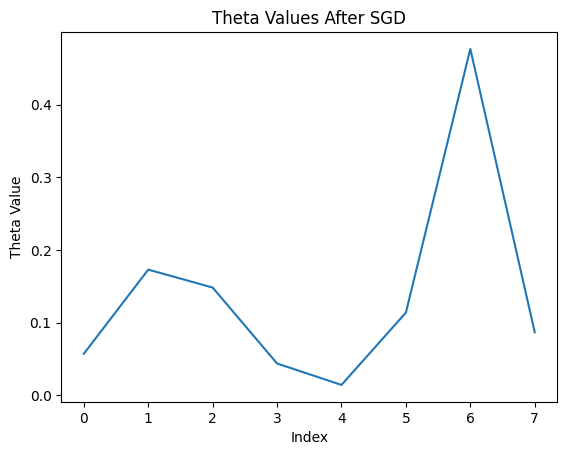

In [46]:
# Normalize X and y to prevent overflow
X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)  # Standardize features
y = (y - np.mean(y)) / np.std(y)  # Standardize target values
y = y.reshape(-1, 1)  # Ensure y is a column vector

# Initialize theta
theta = np.random.randn(X.shape[1], 1)

# Use a smaller learning rate
learning_rate = 0.001

# Run stochastic gradient descent
theta = stochastic_gradiant_descent(X, y, theta, learning_rate=learning_rate)

# Plot the results
plt.plot(theta)
plt.title("Theta Values After SGD")
plt.xlabel("Index")
plt.ylabel("Theta Value")
plt.show()

In [47]:
# Print the final theta values
print("Final theta values:")
print(theta)

Final theta values:
[[0.05700171]
 [0.17283301]
 [0.14814584]
 [0.04362325]
 [0.01412703]
 [0.11369558]
 [0.47664269]
 [0.0866893 ]]


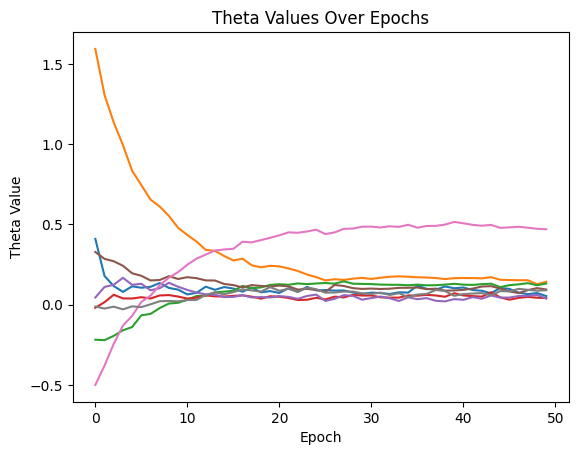

In [48]:
# plot graph to see how it is converging
theta_values = []
theta = np.random.randn(X.shape[1], 1)
for epoch in range(50):
    for i in range(len(X)):
        random_index = np.random.randint(len(X))
        xi = X[random_index:random_index+1]
        yi = y[random_index:random_index+1]
        gradients = 2 * xi.T.dot(xi.dot(theta) - yi)
        theta = theta - learning_rate * gradients
    theta_values.append(theta.copy())
theta_values = np.array(theta_values).squeeze()
plt.plot(theta_values)
plt.title("Theta Values Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Theta Value")
plt.show()

In [49]:
theta_values.shape

(50, 8)